In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. Helper Function ---
def standardize_columns(df):
    new_cols = {}
    for col in df.columns:
        c_low = col.lower()
        if 'weighted' in c_low or 'wacc' in c_low:
            new_cols[col] = 'wacc_std' if 'std' in c_low else 'wacc_mean'
        elif 'accuracy' in c_low or 'acc' in c_low:
            new_cols[col] = 'acc_std' if 'std' in c_low else 'acc_mean'
        elif 'tau' in c_low or 'kendall' in c_low:
            new_cols[col] = 'tau_std' if 'std' in c_low else 'tau_mean'
    return df.rename(columns=new_cols)

# --- 2. Load Experimental Results ---
results_dir = Path("../results")
records = []

if results_dir.exists():
    for spammer_folder in results_dir.iterdir():
        if spammer_folder.is_dir():
            spammer_type = spammer_folder.name
            for csv_file in spammer_folder.glob("*.csv"):
                try:
                    df_temp = pd.read_csv(csv_file)
                    df_temp = standardize_columns(df_temp)
                    df_temp['SpammerType'] = spammer_type
                    df_temp['method'] = csv_file.stem 
                    records.append(df_temp)
                except Exception as e:
                    print(f"Error reading {csv_file}: {e}")

data = pd.concat(records, ignore_index=True) if records else pd.DataFrame()

# --- 3. Load and Inject Baseline (0% results) ---
baseline_csv_path = "../../../real_data/passage/baselines_passage.csv"
if Path(baseline_csv_path).exists():
    baseline_df = pd.read_csv(baseline_csv_path)
    baseline_df = standardize_columns(baseline_df)
    
    # Map "Simple BT" to "BT" (or however it appears in your method_order)
    baseline_df["method"] = baseline_df["Method"].str.lower()
    baseline_df['percent'] = 0
    
    # Create a 0% entry for every SpammerType found in the results
    spammer_types = data['SpammerType'].unique()
    baseline_injections = []
    
    for stype in spammer_types:
        temp_baseline = baseline_df.copy()
        temp_baseline['SpammerType'] = stype
        baseline_injections.append(temp_baseline)
    
    # Merge baseline with experimental data
    data = pd.concat([pd.concat(baseline_injections)] + [data], ignore_index=True)
    
# Final cleaning
data['method'] = data['method'].str.strip().str.lower()
data = data.drop('Method', axis=1)
data = data.sort_values(["SpammerType", "percent", "method"]).reset_index(drop=True)

In [2]:
data.head(10)

,acc_mean,acc_std,wacc_mean,wacc_std,tau_mean,tau_std,method,percent,SpammerType
0,0.681900,0.000000,0.745088,0.000000,0.343486,0.000000,barp,0,anti
1,0.680386,0.000000,0.743299,0.000000,0.340701,0.000000,bt,0,anti
2,0.700173,0.000000,0.759566,0.000000,0.377930,0.000000,crowdbt,0,anti
3,0.694721,0.000000,0.755847,0.000000,0.367637,0.000000,factorbt,0,anti
4,0.695317,0.000000,0.754571,0.000000,0.368762,0.000000,hbtl,0,anti
5,0.692965,0.000000,0.753004,0.000000,0.364321,0.000000,htcv,0,anti
6,0.695882,0.000000,0.755587,0.000000,0.369829,0.000000,pgem,0,anti
7,0.652180,0.000000,0.713038,0.000000,0.289181,0.000000,rc,0,anti
8,0.679938,0.000560,0.742190,0.000610,0.339755,0.001059,barp,10,anti
9,0.677830,0.000437,0.740154,0.000599,0.335798,0.000834,bt,10,anti


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Global Style Configuration
sns.set_style("white")  
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["font.family"] = "serif"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

styles = {
    "crowdbt": dict(
        color="#F58231", marker="v", linestyle="--",
        linewidth=2.2, markersize=7,
        markerfacecolor="white", markeredgewidth=1.3
    ),
    "noisybt": dict(
        color="#3CB44B", marker="^", linestyle="--",
        linewidth=2.2, markersize=7,
        markerfacecolor="white", markeredgewidth=1.3
    ),
    "barp": dict(
        color="#4363D8", marker="o", linestyle=":",
        linewidth=2.2, markersize=7,
        markerfacecolor="white", markeredgewidth=1.3
    ),
    "rc": dict(
        color="#911EB4", marker="X", linestyle="-.",
        linewidth=2.2, markersize=8,
        markerfacecolor="white", markeredgewidth=1.5
    ),
    "bt": dict(
        color="#42D4F4", marker="*", linestyle=(0, (5, 2)),
        linewidth=2.2, markersize=10,
        markerfacecolor="white", markeredgewidth=1.3
    ),
    "hbtl": dict(
        color="#010000", marker="s", linestyle="-",
        linewidth=2.2, markersize=7,
        markerfacecolor="white", markeredgewidth=1.3
    ),
    "htcv": dict(
        color="#E6194B", marker="P", linestyle=(0, (3, 1, 1, 1)),
        linewidth=2.2, markersize=8,
        markerfacecolor="white", markeredgewidth=1.5
    ),
    "pgem": dict(
        color="#F032E6", marker="D", linestyle="dashdot",
        linewidth=2.2, markersize=8,
        markerfacecolor="white", markeredgewidth=1.6
    ),
}

display_names = {
    "crowdbt": "CrowdBT",
    "noisybt": "FactorBT",
    "barp": "BARP",
    "rc": "RC",
    "bt": "BT",
    "hbtl": "HBTL",
    "htcv": "HTCV",
    "pgem": "BoRaEM (ours)",
}


method_order = [
    "bt",
    "rc",
    "crowdbt",
    "noisybt",
    "barp",
    "hbtl",
    "htcv",
    "pgem",  # ours
]

# Descriptive Title Mapping
title_map = {
    "equal": "Uniform Spammer Distribution",
    "anti": "Effect of Anti-Persons",
    "left": "Left-Position Biased Spammers",
    "right": "Right-Position Biased Spammers",
    "random": "Random Spammer Behavior"
}

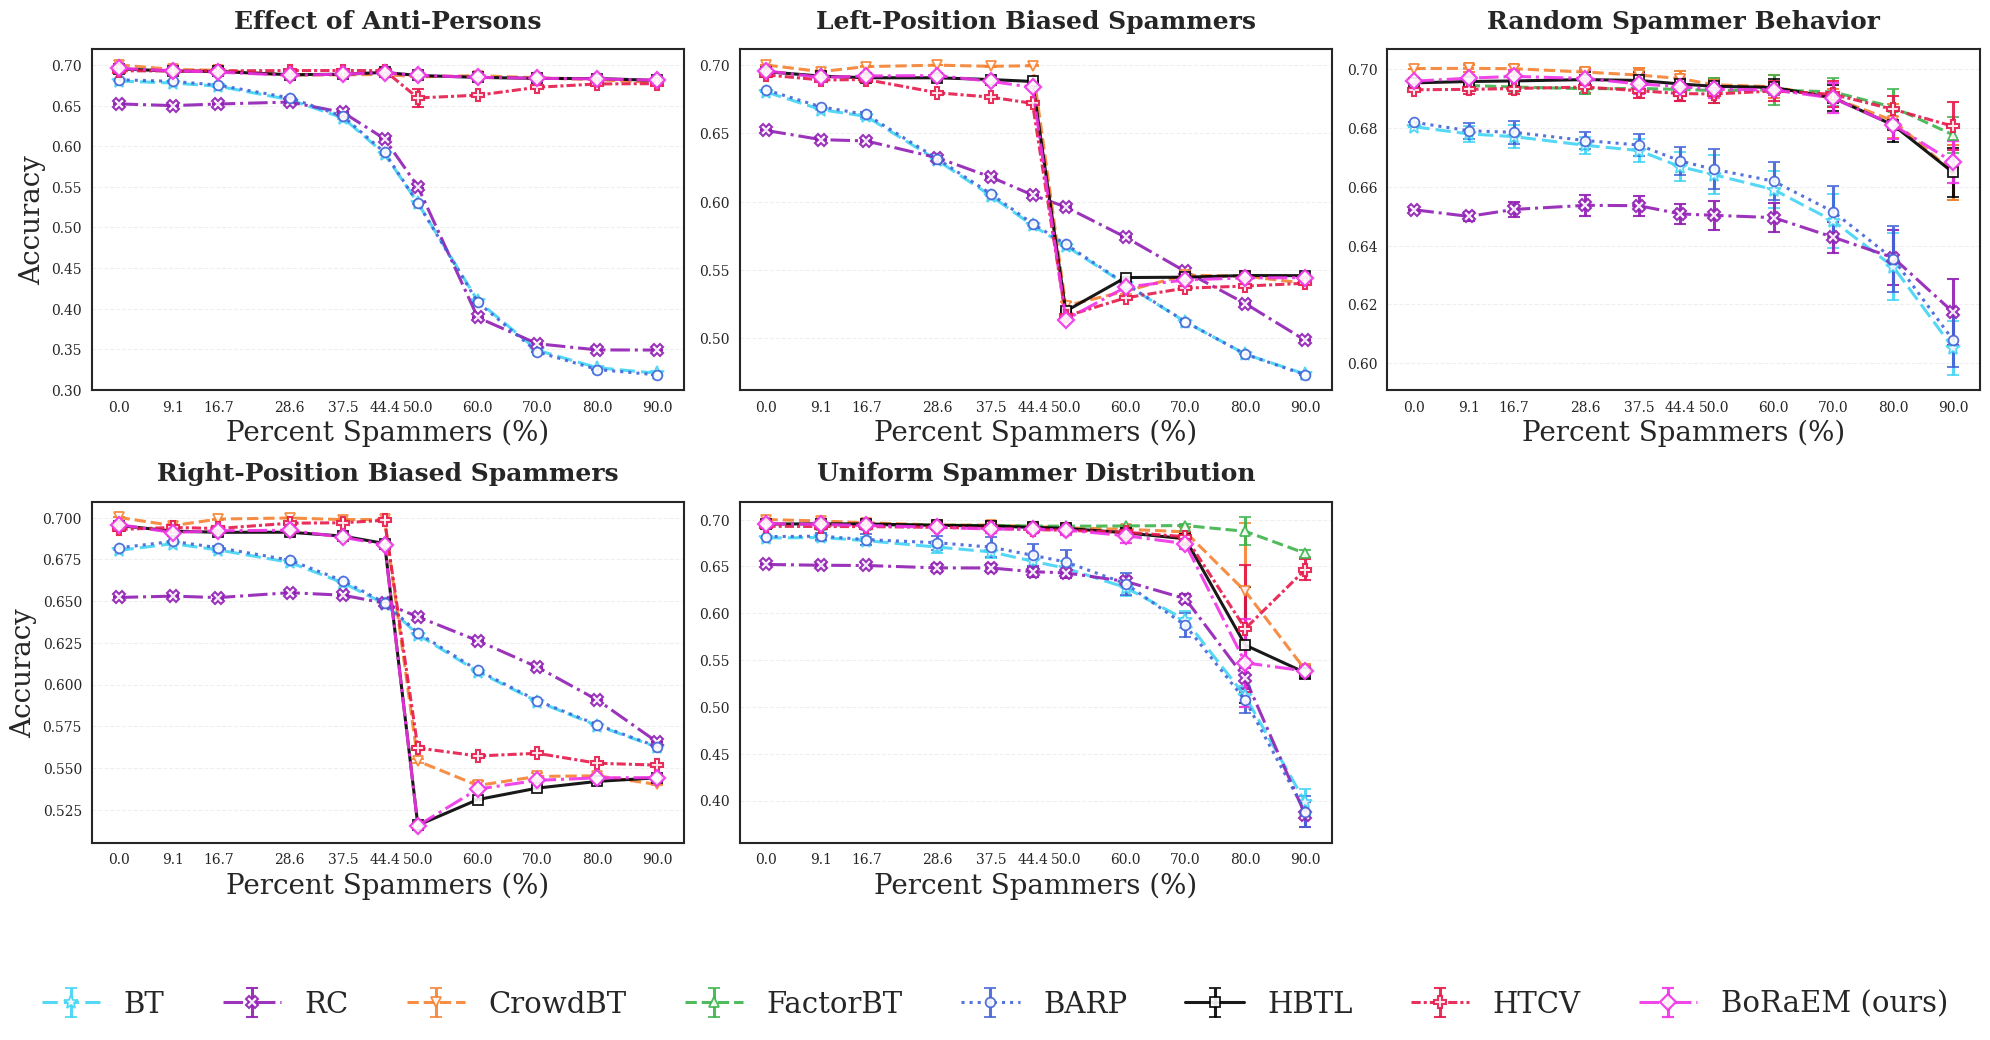

In [4]:
# 3. Setup Grid
all_types = list(data["SpammerType"].unique())
spammer_types = [t for t in all_types if t != "equal"] + (["equal"] if "equal" in all_types else [])

n_types = len(spammer_types)
n_cols = 3
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), squeeze=False, sharey=False)
axes_flat = axes.flatten()

# 4. Plotting Loop
for i, stype in enumerate(spammer_types):
    ax = axes_flat[i]
    subset = data[data["SpammerType"] == stype]
    
    for method in method_order:
        # Filter data for this method (case-insensitive)
        mdf = subset[subset["method"].str.lower() == method.lower()].sort_values("percent")
        if mdf.empty:
            continue
            
        # Apply the style dict using ** unpacking
        ax.errorbar(
            mdf["percent"], 
            mdf["acc_mean"], 
            yerr=mdf.get("acc_std", 0),
            label=display_names.get(method, method),
            capsize=4,
            alpha=0.9,
            **styles[method]  # <--- Unpacks all your custom style parameters
        )

    # Subplot Customization
    ax.set_title(title_map.get(stype, f"Type: {stype}"), fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("Percent Spammers (%)", fontsize=20)
    if i % n_cols == 0:
        ax.set_ylabel("Accuracy", fontsize=20)
    
    # Get unique sorted percent values
    xticks = np.sort(subset["percent"].unique())

    forward = lambda x: x / (100 + x)
    inverse = lambda y: 100 * y / (1 - y)

    ax.set_xscale('function', functions=(forward, inverse))

    # original percent values
    xticks = np.sort(subset["percent"].unique())

    # set ticks at original values
    ax.set_xticks(xticks)

    # labels (in % form after transform)
    xtick_labels = [f"{forward(x)*100:.1f}" for x in xticks]
    ax.set_xticklabels(xtick_labels)

    # limits with padding in transformed space
    xmin, xmax = xticks.min(), xticks.max()
    margin = 0.05 * (forward(xmax) - forward(xmin))

    ax.set_xlim(
        inverse(forward(xmin) - margin),
        inverse(forward(xmax) + margin)
    )
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# 5. Global Legend and Cleanup
# Remove unused axes
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Extract handles and labels for a clean global legend
handles, labels = axes_flat[0].get_legend_handles_labels()
# Ensure legend follows method_order
label_to_handle = dict(zip(labels, handles))
ordered_labels = [display_names[m] for m in method_order if display_names[m] in label_to_handle]
ordered_handles = [label_to_handle[l] for l in ordered_labels]

fig.legend(
    ordered_handles, 
    ordered_labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=len(ordered_labels), 
    fontsize=21,
    frameon=False
)

# fig.suptitle(
#     "Impact of Spammer Proportion Within the Dataset Across Different Spammer Types",
#     fontsize=24,
#     fontweight='bold',
#     y=1.02   # adjust vertical position
# )
plt.tight_layout(rect=[0, 0.08, 1, 1])
# Save with high quality settings
plt.savefig(
    "figures/spammer_analysis_passage_acc.pdf", 
    format="pdf", 
    dpi=300,                # High resolution
    bbox_inches="tight",    # Removes extra whitespace around the plot
    transparent=False        # Useful if placing on a non-white background
)
plt.show()

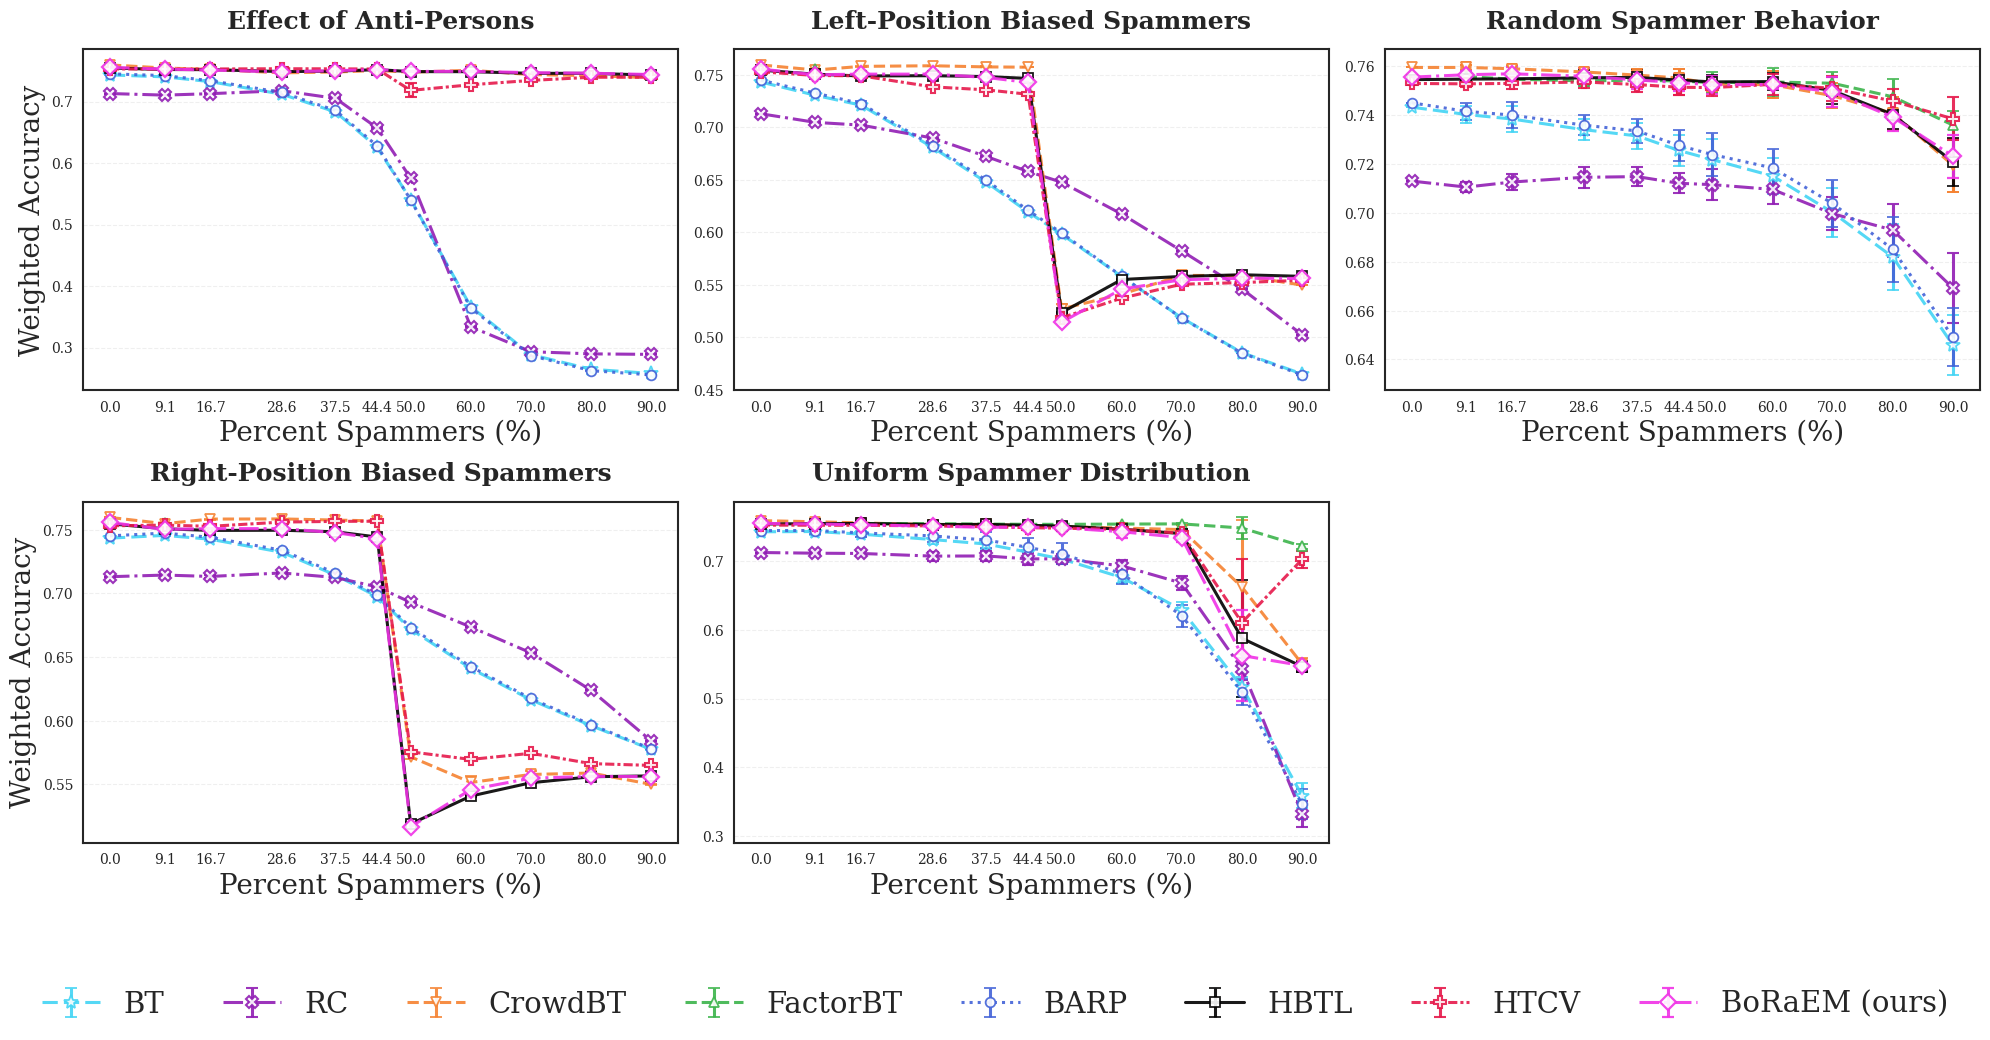

In [5]:
# 3. Setup Grid
all_types = list(data["SpammerType"].unique())
spammer_types = [t for t in all_types if t != "equal"] + (["equal"] if "equal" in all_types else [])

n_types = len(spammer_types)
n_cols = 3
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), squeeze=False, sharey=False)
axes_flat = axes.flatten()

# 4. Plotting Loop
for i, stype in enumerate(spammer_types):
    ax = axes_flat[i]
    subset = data[data["SpammerType"] == stype]
    
    for method in method_order:
        # Filter data for this method (case-insensitive)
        mdf = subset[subset["method"].str.lower() == method.lower()].sort_values("percent")
        if mdf.empty:
            continue
            
        # Apply the style dict using ** unpacking
        ax.errorbar(
            mdf["percent"], 
            mdf["wacc_mean"], 
            yerr=mdf.get("wacc_std", 0),
            label=display_names.get(method, method),
            capsize=4,
            alpha=0.9,
            **styles[method]  # <--- Unpacks all your custom style parameters
        )

    # Subplot Customization
    ax.set_title(title_map.get(stype, f"Type: {stype}"), fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("Percent Spammers (%)", fontsize=20)
    if i % n_cols == 0:
        ax.set_ylabel("Weighted Accuracy", fontsize=20)
    
    # Get unique sorted percent values
    xticks = np.sort(subset["percent"].unique())

    forward = lambda x: x / (100 + x)
    inverse = lambda y: 100 * y / (1 - y)

    ax.set_xscale('function', functions=(forward, inverse))

    # original percent values
    xticks = np.sort(subset["percent"].unique())

    # set ticks at original values
    ax.set_xticks(xticks)

    # labels (in % form after transform)
    xtick_labels = [f"{forward(x)*100:.1f}" for x in xticks]
    ax.set_xticklabels(xtick_labels)

    # limits with padding in transformed space
    xmin, xmax = xticks.min(), xticks.max()
    margin = 0.05 * (forward(xmax) - forward(xmin))

    ax.set_xlim(
        inverse(forward(xmin) - margin),
        inverse(forward(xmax) + margin)
    )
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# 5. Global Legend and Cleanup
# Remove unused axes
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Extract handles and labels for a clean global legend
handles, labels = axes_flat[0].get_legend_handles_labels()
# Ensure legend follows method_order
label_to_handle = dict(zip(labels, handles))
ordered_labels = [display_names[m] for m in method_order if display_names[m] in label_to_handle]
ordered_handles = [label_to_handle[l] for l in ordered_labels]

fig.legend(
    ordered_handles, 
    ordered_labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=len(ordered_labels), 
    fontsize=21,
    frameon=False
)

# fig.suptitle(
#     "Impact of Spammer Proportion Within the Dataset Across Different Spammer Types",
#     fontsize=24,
#     fontweight='bold',
#     y=1.02   # adjust vertical position
# )
plt.tight_layout(rect=[0, 0.08, 1, 1])
# Save with high quality settings
plt.savefig(
    "figures/spammer_analysis_passage_wacc.pdf", 
    format="pdf", 
    dpi=300,                # High resolution
    bbox_inches="tight",    # Removes extra whitespace around the plot
    transparent=False        # Useful if placing on a non-white background
)
plt.show()

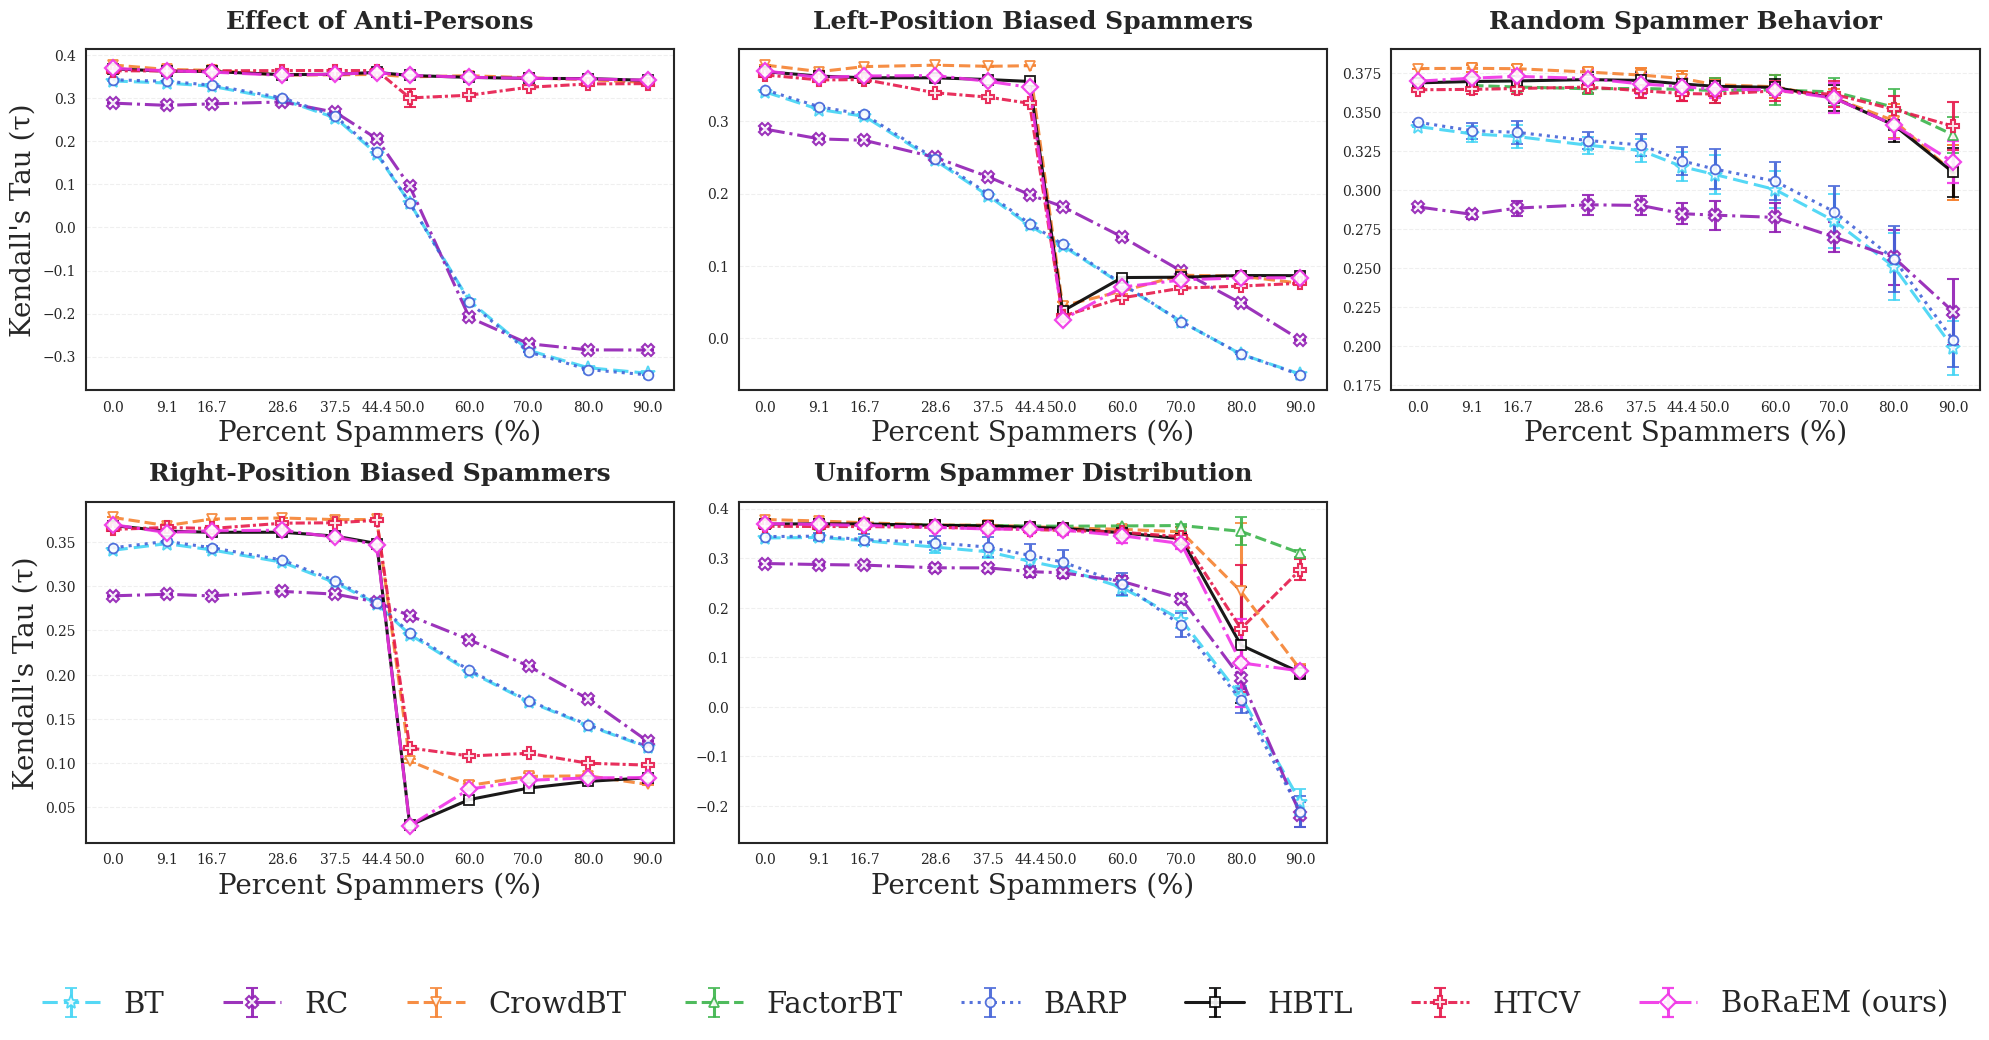

In [6]:
# 3. Setup Grid
all_types = list(data["SpammerType"].unique())
spammer_types = [t for t in all_types if t != "equal"] + (["equal"] if "equal" in all_types else [])

n_types = len(spammer_types)
n_cols = 3
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), squeeze=False, sharey=False)
axes_flat = axes.flatten()

# 4. Plotting Loop
for i, stype in enumerate(spammer_types):
    ax = axes_flat[i]
    subset = data[data["SpammerType"] == stype]
    
    for method in method_order:
        # Filter data for this method (case-insensitive)
        mdf = subset[subset["method"].str.lower() == method.lower()].sort_values("percent")
        if mdf.empty:
            continue
            
        # Apply the style dict using ** unpacking
        ax.errorbar(
            mdf["percent"], 
            mdf["tau_mean"], 
            yerr=mdf.get("tau_std", 0),
            label=display_names.get(method, method),
            capsize=4,
            alpha=0.9,
            **styles[method]  # <--- Unpacks all your custom style parameters
        )

    # Subplot Customization
    ax.set_title(title_map.get(stype, f"Type: {stype}"), fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("Percent Spammers (%)", fontsize=20)
    if i % n_cols == 0:
        ax.set_ylabel("Kendall's Tau (τ)", fontsize=20)
    
    # Get unique sorted percent values
    xticks = np.sort(subset["percent"].unique())

    forward = lambda x: x / (100 + x)
    inverse = lambda y: 100 * y / (1 - y)

    ax.set_xscale('function', functions=(forward, inverse))

    # original percent values
    xticks = np.sort(subset["percent"].unique())

    # set ticks at original values
    ax.set_xticks(xticks)

    # labels (in % form after transform)
    xtick_labels = [f"{forward(x)*100:.1f}" for x in xticks]
    ax.set_xticklabels(xtick_labels)

    # limits with padding in transformed space
    xmin, xmax = xticks.min(), xticks.max()
    margin = 0.05 * (forward(xmax) - forward(xmin))

    ax.set_xlim(
        inverse(forward(xmin) - margin),
        inverse(forward(xmax) + margin)
    )
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# 5. Global Legend and Cleanup
# Remove unused axes
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# Extract handles and labels for a clean global legend
handles, labels = axes_flat[0].get_legend_handles_labels()
# Ensure legend follows method_order
label_to_handle = dict(zip(labels, handles))
ordered_labels = [display_names[m] for m in method_order if display_names[m] in label_to_handle]
ordered_handles = [label_to_handle[l] for l in ordered_labels]

fig.legend(
    ordered_handles, 
    ordered_labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=len(ordered_labels), 
    fontsize=21,
    frameon=False
)

# fig.suptitle(
#     "Impact of Spammer Proportion Within the Dataset Across Different Spammer Types",
#     fontsize=24,
#     fontweight='bold',
#     y=1.02   # adjust vertical position
# )
plt.tight_layout(rect=[0, 0.08, 1, 1])
# Save with high quality settings
plt.savefig(
    "figures/spammer_analysis_passage_tau.pdf", 
    format="pdf", 
    dpi=300,                # High resolution
    bbox_inches="tight",    # Removes extra whitespace around the plot
    transparent=False        # Useful if placing on a non-white background
)
plt.show()